<a href="https://colab.research.google.com/github/Emo4ka07/VKR/blob/main/NTP_%D1%83%D0%B6_%D1%81_%D0%B5%D0%B6%D0%BE%D0%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import random
import numpy as np
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
import matplotlib.pyplot as plt
import json, os

In [6]:
T = 500.0
TRAIN_N = 150
DEMO_N = 2000
X_SCALE = 1000.0
C_SCALE = 1000.0
U_MAX = 500.0
ALPHA_U = 0.01

PARAMS = (0.002, 0.001, 0.49, 0.4632, 0.4425, 505.0, 505.0,
          0.6625, 0.435, 45.0, 30.0, 0.516, 0.45, 0.309, 0.001)

def create_controller():
    return tf.keras.Sequential([
        tf.keras.Input(shape=(4,)),
        tf.keras.layers.Dense(64, activation='leaky_relu'),
        tf.keras.layers.Dense(32, activation='leaky_relu'),
        tf.keras.layers.Dense(16, activation='leaky_relu'),
        tf.keras.layers.Dense(1, activation='tanh')
    ])

def dynamics(x, u_scaled, ctrl_idx, p):
    a1, a2, b1, r1, r2, K1, K2, w1, w2, d1, d2, g1, g2, m, m1 = p
    x1, x2, x3 = x[...,0], x[...,1], x[...,2]
    den1 = d1 + x1 + 1e-6
    den2 = d2 + b1 * tf.square(x2) + 1e-6
    dx1 = r1*x1*(1.0 - (x1 + a1*x2)/K1) - (w1*x1*x3)/den1
    dx2 = r2*x2*(1.0 - (x2 + a2*x1)/K2) - (w2*x2*x3)/den2
    dx3 = (g1*x1*x3)/den1 - (g2*x2*x3)/den2 - m*x3 - m1*tf.square(x3)
    u = tf.reshape(u_scaled, tf.shape(x1))
    if ctrl_idx == 0: dx1 += u
    elif ctrl_idx == 1: dx2 += u
    else: dx3 += u
    return tf.stack([dx1, dx2, dx3], axis=-1)

def simulate_and_loss(x0, C_raw, controller, ctrl_idx, tgt_idx, p, steps):
    batch = tf.shape(x0)[0]
    x = x0
    dt = T / steps
    traj_list, u_list = [], []
    for _ in range(steps):
        x_norm = x / X_SCALE
        C_norm = C_raw / C_SCALE
        inp = tf.concat([x_norm, C_norm], axis=-1)  # (batch, 4)
        u_norm = tf.squeeze(controller(inp), axis=-1)  # (batch,)
        u_scaled = u_norm * U_MAX
        dx = dynamics(x, u_scaled, ctrl_idx, p)
        x = x + dt * dx
        x = tf.clip_by_value(x, 1e-3, 2000.0)
        traj_list.append(x)
        u_list.append(u_norm)
    traj = tf.stack(traj_list, axis=1)
    u_stack = tf.stack(u_list, axis=1)
    C_target = tf.reshape(C_raw, [-1, 1])
    err = (traj[:, :, tgt_idx] - C_target) / X_SCALE
    mse = tf.reduce_mean(tf.square(err))
    u_pen = tf.reduce_mean(tf.square(u_stack))
    return traj, u_stack, mse + ALPHA_U * u_pen

В следующей ячейке обучение

In [ ]:
def make_samples(n):
    xs = np.random.uniform(10.0, 800.0, size=(n,3)).astype(np.float32)
    Cs = np.random.uniform(50.0, 900.0, size=(n,1)).astype(np.float32)
    return xs, np.float32(Cs)

cases = [(c, t) for c in [0, 1] for t in [0, 1, 2]]
print(f"Обучение {len(cases)} специализированных контроллеров: {cases}")

np.random.seed(13)
train_xs, train_Cs = make_samples(300)
test_xs, test_Cs   = make_samples(100)

BATCH_SIZE = 64
train_ds = tf.data.Dataset.from_tensor_slices((train_xs, train_Cs)).shuffle(len(train_xs)).batch(BATCH_SIZE)
test_ds  = tf.data.Dataset.from_tensor_slices((test_xs, test_Cs)).batch(BATCH_SIZE)

case_weights = {}

for ctrl_idx, tgt_idx in cases:
    print(f"\nСлучай: u по x{ctrl_idx+1}, цель по x{tgt_idx+1}")
    controller = create_controller()
    # Явный билд модели (гарантирует создание весов до цикла)
    _ = controller(tf.zeros((1, 4)))

    optimizer = tf.keras.optimizers.Adam(learning_rate=5e-4)
    EPOCHS = 30
    best_loss = float('inf'); patience = 0
    tr_loss, te_loss = [], []

    for epoch in range(1, EPOCHS+1):
        ep_loss = 0.0; nb = 0
        for bx, bC in train_ds:
            with tf.GradientTape() as tape:
                _, _, loss = simulate_and_loss(bx, bC, controller, ctrl_idx, tgt_idx, PARAMS, TRAIN_N)
            grads = tape.gradient(loss, controller.trainable_variables)
            grads, _ = tf.clip_by_global_norm(grads, 1.0)
            optimizer.apply_gradients(zip(grads, controller.trainable_variables))
            ep_loss += loss.numpy(); nb += 1
        tr_loss.append(ep_loss/nb)

        te = 0.0; nbt = 0
        for tx, tC in test_ds:
            _, _, l = simulate_and_loss(tx, tC, controller, ctrl_idx, tgt_idx, PARAMS, TRAIN_N)
            te += l.numpy(); nbt += 1
        te_loss.append(te/nbt)

        if te_loss[-1] < best_loss:
            best_loss = te_loss[-1]; patience = 0
            controller.save_weights(f"/content/drive/MyDrive/ctrl_u{ctrl_idx+1}_t{tgt_idx+1}.weights.h5")
        else:
            patience += 1

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Ep {epoch:2d} | Tr={tr_loss[-1]:.4f} | Te={te_loss[-1]:.4f} | Pat={patience}")
        if patience >= 5:
            print(f"Early stopping"); break

    case_weights[(ctrl_idx, tgt_idx)] = f"ctrl_u{ctrl_idx+1}_t{tgt_idx+1}.weights.h5"
    print(f"Сохранено: {case_weights[(ctrl_idx, tgt_idx)]}")

import json
with open("/content/drive/MyDrive/case_map.json", "w") as f:
    json.dump({f"{k[0]}_{k[1]}": v for k, v in case_weights.items()}, f)

Обучение 6 специализированных контроллеров: [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2)]

Случай: u по x1, цель по x1
  Ep  1 | Tr=0.0579 | Te=0.0428 | Pat=0
  Ep  5 | Tr=0.0628 | Te=0.0619 | Pat=2
Early stopping
Сохранено: ctrl_u1_t1.weights.h5

Случай: u по x1, цель по x2
  Ep  1 | Tr=0.0652 | Te=0.0594 | Pat=0
  Ep  5 | Tr=0.0647 | Te=0.0593 | Pat=3
Early stopping
Сохранено: ctrl_u1_t2.weights.h5

Случай: u по x1, цель по x3
  Ep  1 | Tr=0.2038 | Te=0.1827 | Pat=0
  Ep  5 | Tr=0.1650 | Te=0.1663 | Pat=1
  Ep 10 | Tr=0.1675 | Te=0.1649 | Pat=0
  Ep 15 | Tr=0.2327 | Te=0.2418 | Pat=5
Early stopping
Сохранено: ctrl_u1_t3.weights.h5

Случай: u по x2, цель по x1
  Ep  1 | Tr=0.1401 | Te=0.1401 | Pat=0
  Ep  5 | Tr=0.1413 | Te=0.1398 | Pat=0
  Ep 10 | Tr=0.1406 | Te=0.1396 | Pat=0
  Ep 15 | Tr=0.1404 | Te=0.1396 | Pat=4
  Ep 20 | Tr=0.1401 | Te=0.1395 | Pat=0
  Ep 25 | Tr=0.1408 | Te=0.1395 | Pat=0
  Ep 30 | Tr=0.1404 | Te=0.1395 | Pat=2
Сохранено: ctrl_u2_t1.weights.h5

Случай: u по 

запуск, графики

Загрузка: u по x1, цель по x2


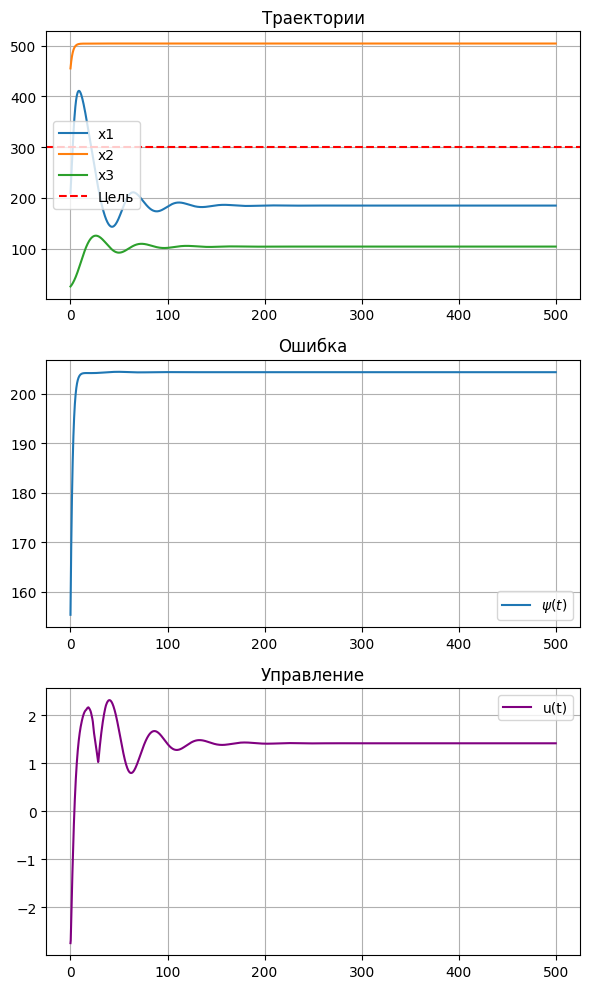

In [13]:
with open("/content/drive/MyDrive/case_map.json") as f:
    CASE_MAP = json.load(f)

def load_controller(ctrl_idx, tgt_idx):
    ctrl = create_controller()
    _ = ctrl(tf.zeros((1, 4)))
    fname = CASE_MAP[f"{ctrl_idx}_{tgt_idx}"]
    path = f"/content/drive/MyDrive/{fname}"
    if not os.path.exists(path):
        raise FileNotFoundError(f"Веса для случая u{ctrl_idx+1}→t{tgt_idx+1} не найдены.")
    ctrl.load_weights(path)
    return ctrl

def simulate_demo(x0, C, ctrl_idx, tgt_idx, controller, p, N_sim=2000):
    T_sim = 500.0; dt_sim = T_sim / N_sim
    x = x0; tr, ur = [], []
    for _ in range(N_sim):
        x_norm = x / X_SCALE; C_norm = C / C_SCALE
        inp = tf.concat([x_norm, C_norm], axis=-1)
        u_norm = tf.squeeze(controller(inp), axis=-1)
        u_scaled = u_norm * U_MAX
        dx = dynamics(x, u_scaled, ctrl_idx, p)
        x = x + dt_sim * dx
        x = tf.clip_by_value(x, 1e-3, 2000.0)
        tr.append(x); ur.append(u_scaled)
    return tf.stack(tr, axis=1).numpy()[0], tf.stack(ur, axis=1).numpy()[0]

# ИНДЕКСЫ
demo_ctrl = 0
demo_tgt  = 1
print(f"Загрузка: u по x{demo_ctrl+1}, цель по x{demo_tgt+1}")
controller = load_controller(demo_ctrl, demo_tgt)

demo_x = np.array([[200.0, 450.0, 25.1]], np.float32)
demo_C = np.array([[300.0]], np.float32)

traj, u = simulate_demo(demo_x, demo_C, demo_ctrl, demo_tgt, controller, PARAMS, DEMO_N)
ts = np.linspace(0, 500.0, len(u))
psi = traj[:, demo_tgt] - demo_C[0,0]

plt.figure(figsize=(6,10))
plt.subplot(3,1,1)
for i, lbl in enumerate(['x1','x2','x3']): plt.plot(ts, traj[:,i], label=lbl)
plt.axhline(demo_C[0,0], color='red', ls='--', label='Цель'); plt.title("Траектории"); plt.grid(); plt.legend()
plt.subplot(3,1,2); plt.plot(ts, psi, label=r'$\psi(t)$'); plt.title("Ошибка"); plt.grid(); plt.legend()
plt.subplot(3,1,3); plt.plot(ts, u, label='u(t)', color='purple'); plt.title("Управление"); plt.grid(); plt.legend()
plt.tight_layout(); plt.show()

Загрузка: u по x2, цель по x1


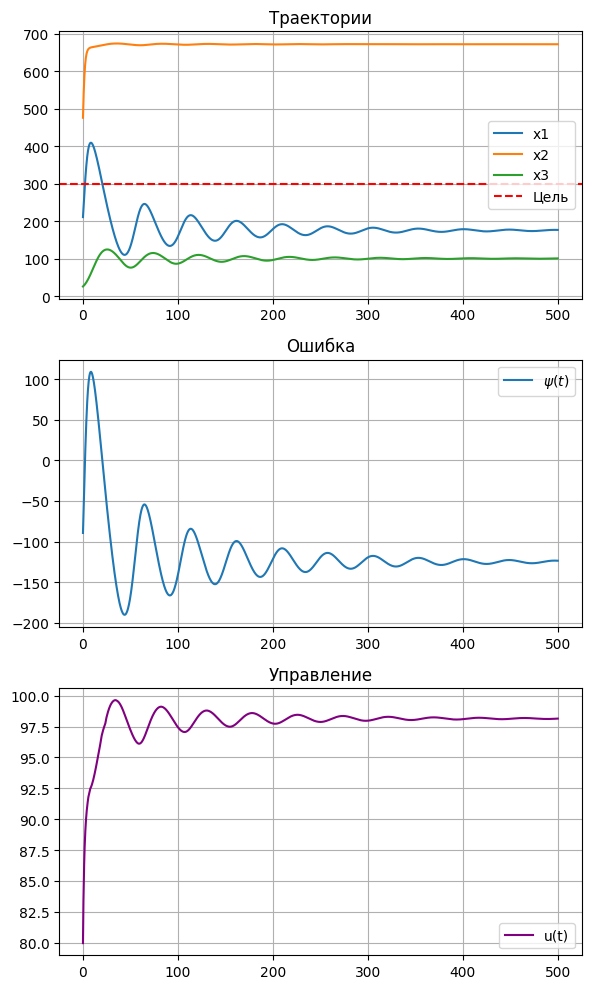

In [14]:
def load_controller(ctrl_idx, tgt_idx):
    ctrl = create_controller()
    _ = ctrl(tf.zeros((1, 4)))
    fname = CASE_MAP[f"{ctrl_idx}_{tgt_idx}"]
    path = f"/content/drive/MyDrive/{fname}"
    if not os.path.exists(path):
        raise FileNotFoundError(f"Веса для случая u{ctrl_idx+1}→t{tgt_idx+1} не найдены.")
    ctrl.load_weights(path)
    return ctrl

def simulate_demo(x0, C, ctrl_idx, tgt_idx, controller, p, N_sim=2000):
    T_sim = 500.0; dt_sim = T_sim / N_sim
    x = x0; tr, ur = [], []
    for _ in range(N_sim):
        x_norm = x / X_SCALE; C_norm = C / C_SCALE
        inp = tf.concat([x_norm, C_norm], axis=-1)
        u_norm = tf.squeeze(controller(inp), axis=-1)
        u_scaled = u_norm * U_MAX
        dx = dynamics(x, u_scaled, ctrl_idx, p)
        x = x + dt_sim * dx
        x = tf.clip_by_value(x, 1e-3, 2000.0)
        tr.append(x); ur.append(u_scaled)
    return tf.stack(tr, axis=1).numpy()[0], tf.stack(ur, axis=1).numpy()[0]

# ИНДЕКСЫ
demo_ctrl = 1
demo_tgt  = 0
print(f"Загрузка: u по x{demo_ctrl+1}, цель по x{demo_tgt+1}")
controller = load_controller(demo_ctrl, demo_tgt)

demo_x = np.array([[200.0, 450.0, 25.1]], np.float32)
demo_C = np.array([[300.0]], np.float32)

traj, u = simulate_demo(demo_x, demo_C, demo_ctrl, demo_tgt, controller, PARAMS, DEMO_N)
ts = np.linspace(0, 500.0, len(u))
psi = traj[:, demo_tgt] - demo_C[0,0]

plt.figure(figsize=(6,10))
plt.subplot(3,1,1)
for i, lbl in enumerate(['x1','x2','x3']): plt.plot(ts, traj[:,i], label=lbl)
plt.axhline(demo_C[0,0], color='red', ls='--', label='Цель'); plt.title("Траектории"); plt.grid(); plt.legend()
plt.subplot(3,1,2); plt.plot(ts, psi, label=r'$\psi(t)$'); plt.title("Ошибка"); plt.grid(); plt.legend()
plt.subplot(3,1,3); plt.plot(ts, u, label='u(t)', color='purple'); plt.title("Управление"); plt.grid(); plt.legend()
plt.tight_layout(); plt.show()

Загрузка: u по x2, цель по x2


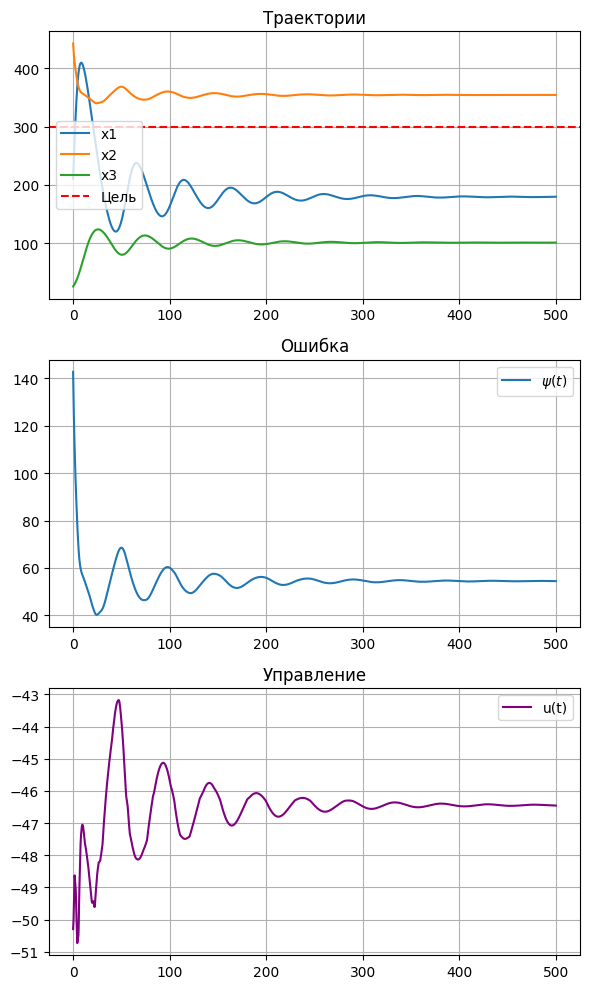

In [15]:
def load_controller(ctrl_idx, tgt_idx):
    ctrl = create_controller()
    _ = ctrl(tf.zeros((1, 4)))
    fname = CASE_MAP[f"{ctrl_idx}_{tgt_idx}"]
    path = f"/content/drive/MyDrive/{fname}"
    if not os.path.exists(path):
        raise FileNotFoundError(f"Веса для случая u{ctrl_idx+1}→t{tgt_idx+1} не найдены.")
    ctrl.load_weights(path)
    return ctrl

def simulate_demo(x0, C, ctrl_idx, tgt_idx, controller, p, N_sim=2000):
    T_sim = 500.0; dt_sim = T_sim / N_sim
    x = x0; tr, ur = [], []
    for _ in range(N_sim):
        x_norm = x / X_SCALE; C_norm = C / C_SCALE
        inp = tf.concat([x_norm, C_norm], axis=-1)
        u_norm = tf.squeeze(controller(inp), axis=-1)
        u_scaled = u_norm * U_MAX
        dx = dynamics(x, u_scaled, ctrl_idx, p)
        x = x + dt_sim * dx
        x = tf.clip_by_value(x, 1e-3, 2000.0)
        tr.append(x); ur.append(u_scaled)
    return tf.stack(tr, axis=1).numpy()[0], tf.stack(ur, axis=1).numpy()[0]

# ИНДЕКСЫ
demo_ctrl = 1
demo_tgt  = 1
print(f"Загрузка: u по x{demo_ctrl+1}, цель по x{demo_tgt+1}")
controller = load_controller(demo_ctrl, demo_tgt)

demo_x = np.array([[200.0, 450.0, 25.1]], np.float32)
demo_C = np.array([[300.0]], np.float32)

traj, u = simulate_demo(demo_x, demo_C, demo_ctrl, demo_tgt, controller, PARAMS, DEMO_N)
ts = np.linspace(0, 500.0, len(u))
psi = traj[:, demo_tgt] - demo_C[0,0]

plt.figure(figsize=(6,10))
plt.subplot(3,1,1)
for i, lbl in enumerate(['x1','x2','x3']): plt.plot(ts, traj[:,i], label=lbl)
plt.axhline(demo_C[0,0], color='red', ls='--', label='Цель'); plt.title("Траектории"); plt.grid(); plt.legend()
plt.subplot(3,1,2); plt.plot(ts, psi, label=r'$\psi(t)$'); plt.title("Ошибка"); plt.grid(); plt.legend()
plt.subplot(3,1,3); plt.plot(ts, u, label='u(t)', color='purple'); plt.title("Управление"); plt.grid(); plt.legend()
plt.tight_layout(); plt.show()

Загрузка: u по x1, цель по x1


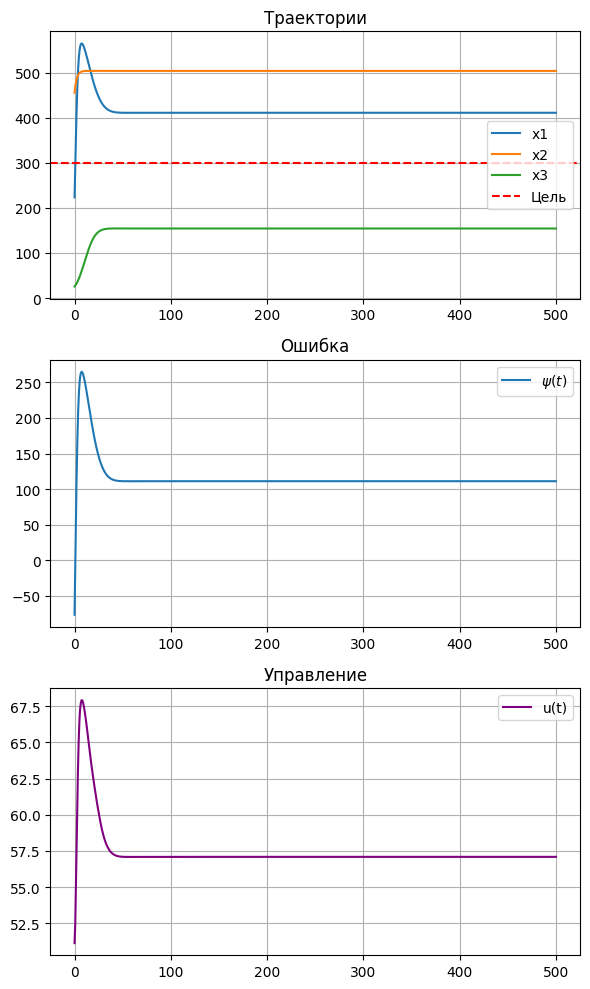

In [16]:
def load_controller(ctrl_idx, tgt_idx):
    ctrl = create_controller()
    _ = ctrl(tf.zeros((1, 4)))
    fname = CASE_MAP[f"{ctrl_idx}_{tgt_idx}"]
    path = f"/content/drive/MyDrive/{fname}"
    if not os.path.exists(path):
        raise FileNotFoundError(f"Веса для случая u{ctrl_idx+1}→t{tgt_idx+1} не найдены.")
    ctrl.load_weights(path)
    return ctrl

def simulate_demo(x0, C, ctrl_idx, tgt_idx, controller, p, N_sim=2000):
    T_sim = 500.0; dt_sim = T_sim / N_sim
    x = x0; tr, ur = [], []
    for _ in range(N_sim):
        x_norm = x / X_SCALE; C_norm = C / C_SCALE
        inp = tf.concat([x_norm, C_norm], axis=-1)
        u_norm = tf.squeeze(controller(inp), axis=-1)
        u_scaled = u_norm * U_MAX
        dx = dynamics(x, u_scaled, ctrl_idx, p)
        x = x + dt_sim * dx
        x = tf.clip_by_value(x, 1e-3, 2000.0)
        tr.append(x); ur.append(u_scaled)
    return tf.stack(tr, axis=1).numpy()[0], tf.stack(ur, axis=1).numpy()[0]

# ИНДЕКСЫ
demo_ctrl = 0
demo_tgt  = 0
print(f"Загрузка: u по x{demo_ctrl+1}, цель по x{demo_tgt+1}")
controller = load_controller(demo_ctrl, demo_tgt)

demo_x = np.array([[200.0, 450.0, 25.1]], np.float32)
demo_C = np.array([[300.0]], np.float32)

traj, u = simulate_demo(demo_x, demo_C, demo_ctrl, demo_tgt, controller, PARAMS, DEMO_N)
ts = np.linspace(0, 500.0, len(u))
psi = traj[:, demo_tgt] - demo_C[0,0]

plt.figure(figsize=(6,10))
plt.subplot(3,1,1)
for i, lbl in enumerate(['x1','x2','x3']): plt.plot(ts, traj[:,i], label=lbl)
plt.axhline(demo_C[0,0], color='red', ls='--', label='Цель'); plt.title("Траектории"); plt.grid(); plt.legend()
plt.subplot(3,1,2); plt.plot(ts, psi, label=r'$\psi(t)$'); plt.title("Ошибка"); plt.grid(); plt.legend()
plt.subplot(3,1,3); plt.plot(ts, u, label='u(t)', color='purple'); plt.title("Управление"); plt.grid(); plt.legend()
plt.tight_layout(); plt.show()

Веса загружены
Демонстрация: u -> x2, цель -> x3


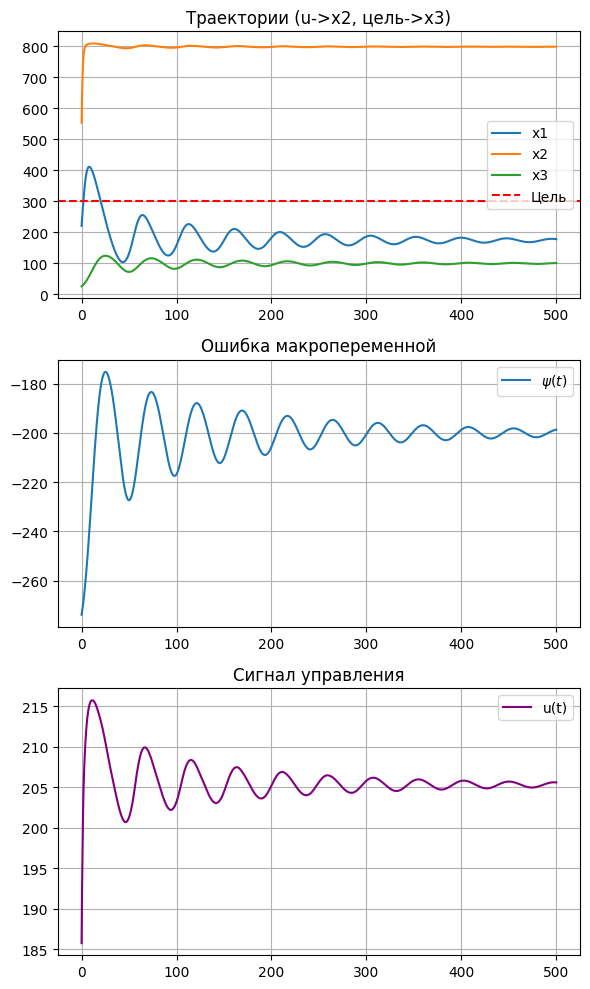

In [ ]:
controller = Controller()
_ = controller(tf.zeros((1,3)), tf.zeros((1,1)), tf.zeros((1,3)), tf.zeros((1,3)))
controller.load_weights("/content/drive/MyDrive/controller_universal.weights.h5")
print("Веса загружены")

def simulate_demo(x0, C, ctrl_idx, tgt_idx, controller, p, N_sim=1000):
    T_sim = 500.0; dt_sim = T_sim / N_sim
    batch = tf.shape(x0)[0]
    ctrl_hot = tf.tile(tf.one_hot([ctrl_idx], 3), [batch, 1])
    tgt_hot  = tf.tile(tf.one_hot([tgt_idx], 3), [batch, 1])

    x = x0
    traj_list, u_list = [], []

    for _ in range(N_sim):
        x_norm = x / X_SCALE; C_norm = C / C_SCALE
        u_norm = controller(x_norm, C_norm, ctrl_hot, tgt_hot)
        u_scaled = u_norm * U_MAX

        dx = dynamics(x, u_scaled, ctrl_idx, p)
        x = x + dt_sim * dx
        x = tf.clip_by_value(x, 1e-3, 2000.0)

        traj_list.append(x)
        u_list.append(u_scaled)

    return tf.stack(traj_list, axis=1).numpy()[0], tf.stack(u_list, axis=1).numpy()[0]

# индексы
demo_ctrl = 1  # управление по: 0->x1, 1->x2, 2->x3
demo_tgt  = 2  # цель:          0->x1, 1->x2, 2->x3
print(f"Демонстрация: u -> x{demo_ctrl+1}, цель -> x{demo_tgt+1}")

demo_x = np.array([[200.0, 450.0, 25.1]], np.float32)
demo_C = np.array([[300.0]], np.float32)

traj, u = simulate_demo(demo_x, demo_C, demo_ctrl, demo_tgt, controller, PARAMS)
ts_plot = np.linspace(0, 500.0, len(u))
psi = traj[:, demo_tgt] - demo_C[0,0]

plt.figure(figsize=(6,10))
plt.subplot(3,1,1)
for i, lbl in enumerate(['x1', 'x2', 'x3']):
    plt.plot(ts_plot, traj[:,i], label=lbl)
plt.axhline(demo_C[0,0], color='red', linestyle='--', label='Цель')
plt.title(f"Траектории (u->x{demo_ctrl+1}, цель->x{demo_tgt+1})")
plt.grid(); plt.legend()

plt.subplot(3,1,2)
plt.plot(ts_plot, psi, label=r'$\psi(t)$')
plt.title("Ошибка макропеременной")
plt.grid(); plt.legend()

plt.subplot(3,1,3)
plt.plot(ts_plot, u, label='u(t)', color='purple')
plt.title("Сигнал управления")
plt.grid(); plt.legend()

plt.tight_layout()
plt.show()

Веса загружены
Демонстрация: u -> x1, цель -> x3


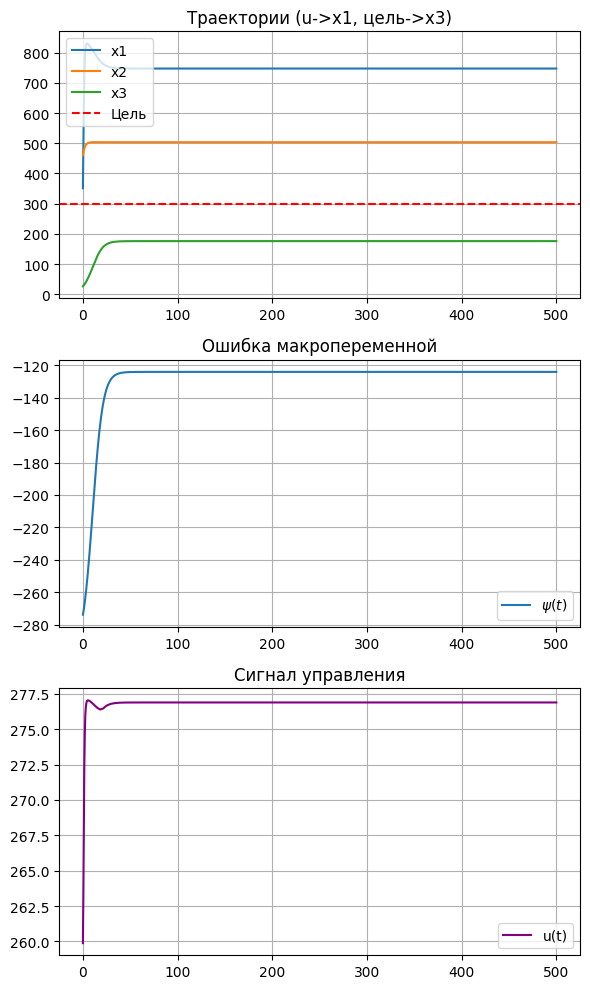

In [ ]:
controller = Controller()
_ = controller(tf.zeros((1,3)), tf.zeros((1,1)), tf.zeros((1,3)), tf.zeros((1,3)))
controller.load_weights("/content/drive/MyDrive/controller_universal.weights.h5")
print("Веса загружены")

def simulate_demo(x0, C, ctrl_idx, tgt_idx, controller, p, N_sim=1000):
    T_sim = 500.0; dt_sim = T_sim / N_sim
    batch = tf.shape(x0)[0]
    ctrl_hot = tf.tile(tf.one_hot([ctrl_idx], 3), [batch, 1])
    tgt_hot  = tf.tile(tf.one_hot([tgt_idx], 3), [batch, 1])

    x = x0
    traj_list, u_list = [], []

    for _ in range(N_sim):
        x_norm = x / X_SCALE; C_norm = C / C_SCALE
        u_norm = controller(x_norm, C_norm, ctrl_hot, tgt_hot)
        u_scaled = u_norm * U_MAX

        dx = dynamics(x, u_scaled, ctrl_idx, p)
        x = x + dt_sim * dx
        x = tf.clip_by_value(x, 1e-3, 2000.0)

        traj_list.append(x)
        u_list.append(u_scaled)

    return tf.stack(traj_list, axis=1).numpy()[0], tf.stack(u_list, axis=1).numpy()[0]

# индексы
demo_ctrl = 0  # управление по: 0->x1, 1->x2, 2->x3
demo_tgt  = 2  # цель:          0->x1, 1->x2, 2->x3
print(f"Демонстрация: u -> x{demo_ctrl+1}, цель -> x{demo_tgt+1}")

demo_x = np.array([[200.0, 450.0, 25.1]], np.float32)
demo_C = np.array([[300.0]], np.float32)

traj, u = simulate_demo(demo_x, demo_C, demo_ctrl, demo_tgt, controller, PARAMS)
ts_plot = np.linspace(0, 500.0, len(u))
psi = traj[:, demo_tgt] - demo_C[0,0]

plt.figure(figsize=(6,10))
plt.subplot(3,1,1)
for i, lbl in enumerate(['x1', 'x2', 'x3']):
    plt.plot(ts_plot, traj[:,i], label=lbl)
plt.axhline(demo_C[0,0], color='red', linestyle='--', label='Цель')
plt.title(f"Траектории (u->x{demo_ctrl+1}, цель->x{demo_tgt+1})")
plt.grid(); plt.legend()

plt.subplot(3,1,2)
plt.plot(ts_plot, psi, label=r'$\psi(t)$')
plt.title("Ошибка макропеременной")
plt.grid(); plt.legend()

plt.subplot(3,1,3)
plt.plot(ts_plot, u, label='u(t)', color='purple')
plt.title("Сигнал управления")
plt.grid(); plt.legend()

plt.tight_layout()
plt.show()